In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
USING_KAGGLE = True
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
private_key = user_secrets.get_secret("private")
public_key = user_secrets.get_secret("public")
private_key = private_key[:35] + private_key[35:-33].replace(' ', '\n') + private_key[-33:] + '\n'
with open('key', 'w') as f:
    f.write(private_key)
with open('key.pub', 'w') as f:
    f.write(public_key)


In [3]:
!mkdir ~/.ssh
!touch ~/.ssh/known_hosts 
!ssh-keyscan -H github.com >> ~/.ssh/known_hosts 
!sudo chmod 600 /kaggle/working/key
!ssh-keyscan -t ecdsa github.com
!GIT_SSH_COMMAND='sudo ssh -i /kaggle/working/key -o IdentitiesOnly=yes -o StrictHostKeyChecking=no -o UserKnownHostsFile=/dev/null' git clone git@github.com:maximspbu/optimizers_comparison.git
!cd optimizers_comparison && git switch sprint5
#!cd optimizers_comparison && git switch sprint5 && GIT_SSH_COMMAND='sudo ssh -i /kaggle/working/key -o IdentitiesOnly=yes -o StrictHostKeyChecking=no -o UserKnownHostsFile=/dev/null' git pull

# github.com:22 SSH-2.0-0264bb16
# github.com:22 SSH-2.0-0264bb16
# github.com:22 SSH-2.0-0264bb16
# github.com:22 SSH-2.0-0264bb16
# github.com:22 SSH-2.0-0264bb16
# github.com:22 SSH-2.0-0264bb16
github.com ecdsa-sha2-nistp256 AAAAE2VjZHNhLXNoYTItbmlzdHAyNTYAAAAIbmlzdHAyNTYAAABBBEmKSENjQEezOmxkZMy7opKgwFB9nkt5YRrYMjNuG5N87uRgg6CLrbo5wAdT/y6v0mKV0U2w0WZ2YB/++Tpockg=
Cloning into 'optimizers_comparison'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 103 (delta 46), reused 77 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 5.47 MiB | 12.35 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Branch 'sprint5' set up to track remote branch 'sprint5' from 'origin'.
Switched to a new branch 'sprint5'


In [4]:
%pip install lion_pytorch adabound torch-optimizer optax ray[tune] adabelief-pytorch==0.2.0 -q
%pip install --upgrade seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.9 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour 

In [ ]:
import time
import inspect

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchmetrics.classification import MulticlassROC
from torchmetrics.classification import Accuracy, F1Score, MulticlassPrecision, MulticlassRecall, MulticlassConfusionMatrix
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2, ToTensor
from torchvision.models import resnet18
from torchinfo import summary

import pandas as pd

import ray
from ray.train.torch import enable_reproducibility
from ray import tune
from ray.tune import JupyterNotebookReporter
from ray.tune.schedulers import ASHAScheduler

from torch.optim import AdamW
from optimizers_comparison.src.optimizers import AdaBound
from torch_optimizer import Adahessian as AdaHessian
from adabelief_pytorch import AdaBelief
from lion_pytorch import Lion

#notebook_dir = os.path.dirname(os.path.abspath("__file__"))

#project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

#if project_root not in sys.path:
#    sys.path.insert(0, project_root)

In [ ]:
from optimizers_comparison.src.config import setup, seed_worker, OPTIMIZERS_PARAMS, DEVICE, TORCH_GENERATOR
from optimizers_comparison.src.utils import create_writer, plot_results, plot_confusion_matrices_results, test_plot_roc_results
from optimizers_comparison.src.engine import train

2025-05-11 07:03:49.056838: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746947029.312431      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746947029.394030      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [7]:
setup(".")

2025-05-11 07:04:04,762	INFO worker.py:1852 -- Started a local Ray instance.
2025-05-11 07:04:04,832	INFO packaging.py:575 -- Creating a file package for local module '.'.
2025-05-11 07:04:04,914	INFO packaging.py:367 -- Pushing file package 'gcs://_ray_pkg_5922a09f20646c3c.zip' (12.10MiB) to Ray cluster...
2025-05-11 07:04:04,998	INFO packaging.py:380 -- Successfully pushed file package 'gcs://_ray_pkg_5922a09f20646c3c.zip'.


{'CPU': 4.0,
 'GPU': 2.0,
 'accelerator_type:T4': 1.0,
 'memory': 20717578650.0,
 'node:172.19.2.2': 1.0,
 'node:__internal_head__': 1.0,
 'object_store_memory': 8878962278.0}


In [8]:
transforms = v2.Compose([ToTensor(),
                         v2.ToDtype(torch.float32, scale=True),
                         v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
cifar_trainset = CIFAR10(root='data',
                         train=True,
                         transform=transforms,
                         download=True)
cifar_testset = CIFAR10(root='data',
                        train=False,
                        transform=transforms,
                        download=True)
cifar_train_subset, cifar_valid_subset = random_split(
    cifar_trainset,
    [int(0.8*len(cifar_trainset)), len(cifar_trainset)-int(0.8*len(cifar_trainset))],
)
classes = ['plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)

100%|██████████| 170M/170M [00:05<00:00, 31.3MB/s] 


Extracting data/cifar-10-python.tar.gz to data
Files already downloaded and verified


In [ ]:
INPUT_SHAPE = 32
HIDDEN_UNITS = 64
OUTPUT_SHAPE = num_classes
NUM_EPOCHS = 5
EPOCH_STEP = 1
BATCH_SIZE = 256
SEED = 0

OPTIMIZERS_PARAMS: dict = {
    AdaHessian: {
        "lr": tune.grid_search([1e-2, 1e-1, 0.15, 1.0]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
        "hessian_power": tune.grid_search([0.5, 0.75, 1.0]),
        "seed": tune.grid_search([SEED]),
    },
    Lion: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "weight_decay": tune.grid_search([1e-4, 1e-3, 1e-2]),
        "decoupled_weight_decay": tune.grid_search([False, True]),
        "use_triton": tune.grid_search([False]),
    },
    AdaBelief: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
        "amsgrad": tune.grid_search([False, True]),
        "weight_decouple": tune.grid_search([False, True]),
        "rectify": tune.grid_search([False, True]),
        "print_change_log": tune.grid_search([False]),
    },
    AdamW: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
        "amsgrad": tune.grid_search([False, True]),
    },
    AdaBound: {
        "lr": tune.grid_search([1e-5, 1e-4, 1e-3, 1e-2]),
        "final_lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "gamma": tune.grid_search([1e-4, 1e-3, 1e-2]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3]),
        "amsbound": tune.grid_search([False, True]),
    },
}

writer = create_writer(
    experiment_name="image_classification",
    model_name="simple_cls_model", 
)

cls_analysis_optimizer = {}
classification_metrics = {"accuracy": Accuracy("multiclass", num_classes=num_classes), 
                          "f1score": F1Score("multiclass", num_classes=num_classes),
                          "precision": MulticlassPrecision(num_classes=num_classes),
                          "recall": MulticlassRecall(num_classes=num_classes),}
reporter = JupyterNotebookReporter(metric_columns=["test_loss"], 
                                   mode="min", 
                                   print_intermediate_tables=False)

cifar_train_subset_ref = ray.put(cifar_train_subset)
cifar_valid_subset_ref = ray.put(cifar_valid_subset)
cifar_testset_ref = ray.put(cifar_testset)

for metric in classification_metrics:
    reporter.add_metric_column(f"valid_{metric}")

for optimizer_type in OPTIMIZERS_PARAMS.keys():
    
    def wrap(config: dict) -> None:
        """Wrapper function for tuning hyperparameters.
    
        Args:
            config: A dict whose keys are parameters to be tuned and values that the parameter can take.

        """
        cifar_train_dataloader = DataLoader(dataset=ray.get(cifar_train_subset_ref),
                                           batch_size=BATCH_SIZE,
                                           shuffle=True,
                                           num_workers=2,
                                           worker_init_fn=seed_worker,
                                           generator=TORCH_GENERATOR,)
        cifar_valid_dataloader = DataLoader(dataset=ray.get(cifar_valid_subset_ref),
                                           batch_size=BATCH_SIZE,
                                           shuffle=True,
                                           num_workers=2,
                                           worker_init_fn=seed_worker,
                                           generator=TORCH_GENERATOR,)
        cifar_test_dataloader = DataLoader(dataset=ray.get(cifar_testset_ref),
                                           batch_size=BATCH_SIZE,
                                           shuffle=True,
                                           num_workers=2,
                                           worker_init_fn=seed_worker,
                                           generator=TORCH_GENERATOR,)
        
        model = resnet18(num_classes=num_classes).to(DEVICE)
        loss_fn = torch.nn.CrossEntropyLoss()
        optimizer = optimizer_type(model.parameters(), **{i: config[i] for i in config if i in OPTIMIZERS_PARAMS[optimizer_type]})
        d = train(
             model=model,
             train_dataloader=cifar_train_dataloader,
             valid_dataloader=cifar_valid_dataloader,
             test_dataloader=cifar_test_dataloader,
             loss_fn=loss_fn,
             metrics=classification_metrics,
             optimizer=optimizer,
             epochs=NUM_EPOCHS,
             device=DEVICE,
             #scheduler=scheduler,
             epoch_step=EPOCH_STEP,
         )
        tune.report(
            {"test_loss": d["test_loss"][0]}
            | {f"test_{str(i)}": d[f"test_{str(i)}"][0] for i in classification_metrics}
        )
        
    analysis = tune.run(
        wrap,
        config={str(key): value for key, value in OPTIMIZERS_PARAMS[optimizer_type].items()},
        scheduler=ASHAScheduler(metric='test_accuracy', mode='max'),
        progress_reporter=reporter,
        resources_per_trial={"cpu": 2, 
                             "gpu": 1,
                             },
        log_to_file=True,
    )
    cls_analysis_optimizer[optimizer_type] = analysis


2025-05-11 07:28:23,136	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(pid=528) 2025-05-11 07:28:47.925812: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=528) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=528) E0000 00:00:1746948527.950353     528 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=528) E0000 00:00:1746948527.957715     528 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(wrap pid=527) /usr/local/lib/python3.11/dist-packages/torch/a

Trial name,test_accuracy,test_f1score,test_loss,test_precision,test_recall
wrap_85393_00000,0.5354,0.5354,1.40233,0.532667,0.5354
wrap_85393_00001,0.5012,0.5012,1.65194,0.503307,0.5012
wrap_85393_00002,0.4983,0.4983,1.86825,0.495862,0.4983
wrap_85393_00003,0.6692,0.6692,0.984971,0.684502,0.6692
wrap_85393_00004,0.6779,0.6779,0.956531,0.704238,0.6779
wrap_85393_00005,0.6631,0.6631,1.03086,0.670277,0.6631
wrap_85393_00006,0.6817,0.6817,0.949688,0.697072,0.6817
wrap_85393_00007,0.6325,0.6325,1.09408,0.65035,0.6325
wrap_85393_00008,0.6766,0.6766,0.96737,0.698448,0.6766
wrap_85393_00009,0.6108,0.6108,1.11406,0.620216,0.6108


(pid=965) 2025-05-11 07:31:41.055518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(wrap pid=528) /usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:825: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at ../torch/csrc/autograd/engine.cpp:1201.)
(wrap pid=528)   return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
(pid=965) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=965) E0000 00:00:1746948701.080598    

Trial name,test_accuracy,test_f1score,test_loss,test_precision,test_recall
wrap_dcbc8_00000,0.6845,0.6845,1.09514,0.684881,0.6845
wrap_dcbc8_00001,0.6909,0.6909,1.0439,0.695863,0.6909
wrap_dcbc8_00002,0.704,0.704,0.883225,0.706344,0.704
wrap_dcbc8_00003,0.7023,0.7023,0.893991,0.710858,0.7023
wrap_dcbc8_00004,0.588,0.588,1.17322,0.597609,0.588
wrap_dcbc8_00005,0.5558,0.5558,1.56083,0.560455,0.5558
wrap_dcbc8_00006,0.1,0.1,2.32004,0.01,0.1
wrap_dcbc8_00007,0.1,0.1,2.30984,0.01,0.1
wrap_dcbc8_00008,0.6847,0.6847,1.08424,0.691266,0.6847
wrap_dcbc8_00009,0.697,0.697,0.907662,0.70886,0.697


(pid=12739) 2025-05-11 08:43:54.911233: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=12739) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster]
(pid=12739) E0000 00:00:1746953034.934553   12739 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=12739) E0000 00:00:1746953034.941582   12739 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered [r

...

2025-05-11 10:31:25,888	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/wrap_2025-05-11_08-58-52' in 0.0599s.
2025-05-11 10:31:25,913	INFO tune.py:1041 -- Total run time: 5553.79 seconds (5553.67 seconds for the tuning loop).
2025-05-11 10:31:26,042	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(pid=47458) 2025-05-11 10:31:32.472165: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=47458) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=47458) E0000 00:00:1746959492.494606   47458 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin 

Trial name,test_accuracy,test_f1score,test_loss,test_precision,test_recall
wrap_178a8_00000,0.5318,0.5318,1.61093,0.541208,0.5318
wrap_178a8_00001,0.5272,0.5272,1.59986,0.530681,0.5272
wrap_178a8_00002,0.6924,0.6924,0.947355,0.709163,0.6924
wrap_178a8_00003,0.6619,0.6619,1.0485,0.695553,0.6619
wrap_178a8_00004,0.6803,0.6803,1.00132,0.695189,0.6803
wrap_178a8_00005,0.6408,0.6408,1.04623,0.661284,0.6408
wrap_178a8_00006,0.2145,0.2145,1.95365,0.168614,0.2145
wrap_178a8_00007,0.2481,0.2481,1.85205,0.181673,0.2481
wrap_178a8_00008,0.5367,0.5367,1.58109,0.53808,0.5367
wrap_178a8_00009,0.53,0.53,1.59313,0.53212,0.53


(pid=47935) 2025-05-11 10:32:54.439036: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=47935) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=47935) E0000 00:00:1746959574.461503   47935 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=47935) E0000 00:00:1746959574.468332   47935 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=47938) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=47938) E0000 00:00:1746959574.566187   47938 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already bee

Trial name,test_accuracy,test_f1score,test_loss,test_precision,test_recall
wrap_236a5_00000,0.4137,0.4137,1.6362,0.407017,0.4137
wrap_236a5_00001,0.4137,0.4137,1.62493,0.406417,0.4137
wrap_236a5_00002,0.429,0.429,1.59326,0.423912,0.429
wrap_236a5_00003,0.4395,0.4395,1.5673,0.43522,0.4395
wrap_236a5_00004,0.4417,0.4417,1.55903,0.438128,0.4417
wrap_236a5_00005,0.4447,0.4447,1.55115,0.439632,0.4447
wrap_236a5_00006,0.4961,0.4961,1.39782,0.493991,0.4961
wrap_236a5_00007,0.4902,0.4902,1.39846,0.486117,0.4902
wrap_236a5_00008,0.3321,0.3321,1.87725,0.325024,0.3321
wrap_236a5_00009,0.3368,0.3368,1.84491,0.329995,0.3368


(pid=55124) 2025-05-11 10:54:48.303877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=55124) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster]
(pid=55124) E0000 00:00:1746960888.326543   55124 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=55124) E0000 00:00:1746960888.333620   55124 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered [repeated 2x across cluster]
(pid=55568) 2025-05-11 10:56:12.709468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT w

In [13]:
optimizer_comparison_acc_df = pd.DataFrame({"Optimizer": [repr(i)[repr(i).rfind('.') + 1: -2] for i in cls_analysis_optimizer], 
                                        "Config": [i.get_best_config(metric=f"test_accuracy", mode="max") for i in cls_analysis_optimizer.values()], 
                                        "Accuracy": [i.get_best_trial(metric=f"test_accuracy", mode="max").last_result[f"test_accuracy"] for i in cls_analysis_optimizer.values()], 
                                        "Time_total_s": [i.get_best_trial(metric=f"test_accuracy", mode="max").last_result['time_total_s'] for i in cls_analysis_optimizer.values()],
                                       })

optimizer_comparison_acc_df

,Optimizer,Config,Accuracy,Time_total_s
0,Adahessian,"{'lr': 0.15, 'weight_decay': 0.0001, 'hessian_power': 0.75, 'seed': 0}",0.6923,170.386461
1,Lion,"{'lr': 0.001, 'weight_decay': 0.001, 'decoupled_weight_decay': False, 'use_triton': False}",0.7223,69.279341
2,AdaBelief,"{'lr': 0.01, 'weight_decay': 0.001, 'amsgrad': False, 'weight_decouple': True, 'rectify': True, 'print_change_log': False}",0.7117,72.120960
3,AdamW,"{'lr': 0.001, 'weight_decay': 0, 'amsgrad': False}",0.6924,68.422461
4,AdaBound,"{'lr': 0.001, 'final_lr': 0.1, 'gamma': 0.0001, 'weight_decay': 0.0001, 'amsbound': False}",0.6988,73.979855


In [14]:
optimizer_comparison_f1_df = pd.DataFrame({"Optimizer": [repr(i)[repr(i).rfind('.') + 1: -2] for i in cls_analysis_optimizer], 
                                        "Config": [i.get_best_config(metric=f"test_f1score", mode="max") for i in cls_analysis_optimizer.values()], 
                                        "F1Score": [i.get_best_trial(metric=f"test_f1score", mode="max").last_result[f"test_f1score"] for i in cls_analysis_optimizer.values()], 
                                        "Time_total_s": [i.get_best_trial(metric=f"test_f1score", mode="max").last_result['time_total_s'] for i in cls_analysis_optimizer.values()],
                                       })

optimizer_comparison_f1_df

,Optimizer,Config,F1Score,Time_total_s
0,Adahessian,"{'lr': 0.15, 'weight_decay': 0.0001, 'hessian_power': 0.75, 'seed': 0}",0.6923,170.386461
1,Lion,"{'lr': 0.001, 'weight_decay': 0.001, 'decoupled_weight_decay': False, 'use_triton': False}",0.7223,69.279341
2,AdaBelief,"{'lr': 0.01, 'weight_decay': 0.001, 'amsgrad': False, 'weight_decouple': True, 'rectify': True, 'print_change_log': False}",0.7117,72.120960
3,AdamW,"{'lr': 0.001, 'weight_decay': 0, 'amsgrad': False}",0.6924,68.422461
4,AdaBound,"{'lr': 0.001, 'final_lr': 0.1, 'gamma': 0.0001, 'weight_decay': 0.0001, 'amsbound': False}",0.6988,73.979855


**Анализ оптимизаторов:**

1.  **Adahessian**
    *   Accuracy/F1: 0.6923
    *   Конфигурация: Высокий LR (0.15), слабая регуляризация (WD=0.0001).
    *   Анализ: Показал одну из самых низких точностей, сравнимую с AdamW. Время обучения составило 170s, что более чем в 2.4 раза дольше, чем у других оптимизаторов. Это делает его применение для данной задачи менее эффективным с точки зрения скорости.
    *   Итог: Низкая точность и самая низкая скорость.

2.  **Lion**
    *   Accuracy/F1: 0.7223 (Наилучший результат)
    *   Конфигурация: Низкий LR (0.001), умеренная регуляризация (WD=0.001).
    *   Анализ: Lion продемонстрировал наилучшую точность среди всех оптимизаторов. Скорость обучения составила 69.3s, что является одной из самых высоких, незначительно уступая AdamW (68.4s).
    *   Итог: Наилучшая точность и высокая скорость.

3.  **AdaBelief**
    *   Accuracy/F1: 0.7117 (Второй результат)
    *   Конфигурация: Умеренный LR (0.01), умеренная регуляризация (WD=0.001), `weight_decouple` и `rectify` включены.
    *   Анализ: Занял второе место по точности, уступив Lion, но превзойдя остальные оптимизаторы. Скорость обучения составила 72.1s, что является хорошим показателем, но несколько выше, чем у Lion и AdamW.
    *   Итог: Высокая точность (второе место) и хорошая скорость.

4.  **AdamW**
    *   Accuracy/F1: 0.6924
    *   Конфигурация: Низкий LR (0.001), без регуляризации (WD=0).
    *   Анализ: Показал одну из самых низких точностей (0.6924), сравнимую с Adahessian. При этом он оказался самым быстрым оптимизатором (68.4s), с небольшим отрывом от Lion.
    *   Итог: Низкая точность, но самая высокая скорость.

5.  **AdaBound**
    *   Accuracy/F1: 0.6988
    *   Конфигурация: Низкий LR (0.001), слабая регуляризация (WD=0.0001).
    *   Анализ: Точность (0.6988) немного выше, чем у Adahessian и AdamW, но ниже, чем у Lion и AdaBelief. Скорость обучения составила 74.0s, что является хорошим показателем, но выше, чем у более быстрых оптимизаторов.
    *   Итог: Умеренная точность и умеренная скорость.

**Обзор:**  
1.  **Производительность:** По результатам тестирования для задачи классификации изображений на CIFAR-10 с моделью ResNet18, Lion показал наилучшее сочетание точности и скорости, обеспечив самую высокую точность и одну из самых высоких скоростей обучения.
2.  **Диапазон результатов:** Разница в точности между лучшим (Lion, 0.7223) и худшими (Adahessian/AdamW, около 0.692) составляет примерно 3%. Разница в скорости обучения между Adahessian и остальными оптимизаторами существенна.
3.  **Скорость:** За исключением Adahessian, время обучения для остальных оптимизаторов находилось в диапазоне 68-74 секунд. AdamW и Lion показали наименьшее время обучения.
4.  **Параметры:** Для большинства оптимизаторов (Lion, AdamW, AdaBound) оптимальным оказался низкий LR (0.001). AdaBelief потребовал LR=0.01, а Adahessian - высокий LR=0.15. Регуляризация была либо слабой (0.0001), либо умеренной (0.001), либо отсутствовала (AdamW).

Для задачи классификации CIFAR-10 с моделью ResNet18, Lion демонстрирует наиболее высокую производительность, достигая наилучших показателей точности при высокой скорости обучения. AdaBelief является перспективным вариантом, показавшим вторую лучшую точность. AdamW обладает самой высокой скоростью, однако его точность ниже. Adahessian показывает наименьшую эффективность для данной задачи из-за самой низкой скорости обучения и невысокой точности.

In [15]:
results = {}
TEST_NUM_EPOCHS = 21
TEST_EPOCH_STEP = 1

cifar_train_dataloader = DataLoader(dataset=ray.get(cifar_train_subset_ref),
                                   batch_size=BATCH_SIZE,
                                   shuffle=True,
                                   num_workers=2,
                                   worker_init_fn=seed_worker,
                                   generator=TORCH_GENERATOR,)
cifar_valid_dataloader = DataLoader(dataset=ray.get(cifar_valid_subset_ref),
                                   batch_size=BATCH_SIZE,
                                   shuffle=True,
                                   num_workers=2,
                                   worker_init_fn=seed_worker,
                                   generator=TORCH_GENERATOR,)
cifar_test_dataloader = DataLoader(dataset=ray.get(cifar_testset_ref),
                                   batch_size=BATCH_SIZE,
                                   shuffle=True,
                                   num_workers=2,
                                   worker_init_fn=seed_worker,
                                   generator=TORCH_GENERATOR,)

classification_metrics = {"accuracy": Accuracy("multiclass", num_classes=num_classes), 
                          "f1score": F1Score("multiclass", num_classes=num_classes),
                          "precision": MulticlassPrecision(num_classes=num_classes),
                          "recall": MulticlassRecall(num_classes=num_classes),
                          "confusion_matrix": MulticlassConfusionMatrix(num_classes=num_classes),
                          "multiclass_roc": MulticlassROC(num_classes=num_classes)
                          }

for optimizer_type, config in zip(OPTIMIZERS_PARAMS.keys(), optimizer_comparison_f1_df["Config"]):
    model = resnet18(num_classes=num_classes).to(DEVICE)
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = optimizer_type(model.parameters(), **{i: config[i] for i in config if i in OPTIMIZERS_PARAMS[optimizer_type]})
    start = time.perf_counter()
    d = train(
             model=model,
             train_dataloader=cifar_train_dataloader,
             valid_dataloader=cifar_valid_dataloader,
             test_dataloader=cifar_test_dataloader,
             loss_fn=loss_fn,
             metrics=classification_metrics,
             optimizer=optimizer,
             epochs=TEST_NUM_EPOCHS,
             device=DEVICE,
             #scheduler=scheduler,
             epoch_step=TEST_EPOCH_STEP,
         )
    end = time.perf_counter()
    time_training = end - start
    d['time_training'] = [time_training]
    optimizer_name = str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
    print(f"{optimizer_name} was trained for {time_training} seconds")
    results[optimizer_name] = d

/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:825: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at ../torch/csrc/autograd/engine.cpp:1201.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adahessian was trained for 684.6218150210007 seconds
Lion was trained for 239.8233127679996 seconds
Weight decoupling enabled in AdaBelief
Rectification enabled in AdaBelief
AdaBelief was trained for 245.20258064600057 seconds
AdamW was trained for 238.72590648599726 seconds
AdaBound was trained for 246.8186076029997 seconds


In [16]:
default_results = {}

classification_metrics = {"accuracy": Accuracy("multiclass", num_classes=num_classes), 
                          "f1score": F1Score("multiclass", num_classes=num_classes),
                          "precision": MulticlassPrecision(num_classes=num_classes),
                          "recall": MulticlassRecall(num_classes=num_classes),
                          "confusion_matrix": MulticlassConfusionMatrix(num_classes=num_classes),
                          "multiclass_roc": MulticlassROC(num_classes=num_classes)
                          }

for optimizer_type, config in zip(OPTIMIZERS_PARAMS.keys(), optimizer_comparison_f1_df["Config"]):
    model = resnet18(num_classes=num_classes).to(DEVICE)
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = optimizer_type(model.parameters())
    start = time.perf_counter()
    d = train(
             model=model,
             train_dataloader=cifar_train_dataloader,
             valid_dataloader=cifar_valid_dataloader,
             test_dataloader=cifar_test_dataloader,
             loss_fn=loss_fn,
             metrics=classification_metrics,
             optimizer=optimizer,
             epochs=TEST_NUM_EPOCHS,
             device=DEVICE,
             #scheduler=scheduler,
             epoch_step=TEST_EPOCH_STEP,
         )
    end = time.perf_counter()
    time_training = end - start
    d['time_training'] = [time_training]
    optimizer_name = "default_" + str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
    print(f"{optimizer_name} was trained for {time_training} seconds")
    default_results[optimizer_name] = d


default_Adahessian was trained for 689.6523965009983 seconds
default_Lion was trained for 238.96186986700195 seconds
Please check your arguments if you have upgraded adabelief-pytorch from version 0.0.5.
Modifications to default arguments:
                           eps  weight_decouple    rectify
-----------------------  -----  -----------------  ---------
adabelief-pytorch=0.0.5  1e-08  False              False
>=0.1.0 (Current 0.2.0)  1e-16  True               True
SGD better than Adam (e.g. CNN for Image Classification)    Adam better than SGD (e.g. Transformer, GAN)
----------------------------------------------------------  ----------------------------------------------
Recommended eps = 1e-8                                      Recommended eps = 1e-16
For a complete table of recommended hyperparameters, see
https://github.com/juntang-zhuang/Adabelief-Optimizer
You can disable the log message by setting "print_change_log = False", though it is recommended to keep as a reminder.



In [17]:
results_df = (
    pd.DataFrame(results)
    .T[["test_loss", "test_accuracy", "test_precision", "test_recall", "test_f1score", "time_training"]]
    .map(lambda x: x[0])
)

results_df = pd.concat([results_df, pd.DataFrame(optimizer_comparison_f1_df['Config']).set_index(results_df.index)], axis=1)

default_results_df = (
    pd.DataFrame(default_results)
    .T[["test_loss", "test_accuracy", "test_precision", "test_recall", "test_f1score", "time_training"]]
    .map(lambda x: x[0])
)
default_results_df['Config'] = [{i: j for i, j in zip(inspect.getfullargspec(optimizer.__init__).args[2:], inspect.getfullargspec(optimizer.__init__).defaults)} for optimizer in OPTIMIZERS_PARAMS]

pd.concat([results_df, default_results_df])

,test_loss,test_accuracy,test_precision,test_recall,test_f1score,time_training,Config
Adahessian,1.424873,0.7283,0.732972,0.7283,0.7283,684.621815,"{'lr': 0.15, 'weight_decay': 0.0001, 'hessian_power': 0.75, 'seed': 0}"
Lion,1.537992,0.7324,0.735267,0.7324,0.7324,239.823313,"{'lr': 0.001, 'weight_decay': 0.001, 'decoupled_weight_decay': False, 'use_triton': False}"
AdaBelief,1.139034,0.7531,0.755961,0.7531,0.7531,245.202581,"{'lr': 0.01, 'weight_decay': 0.001, 'amsgrad': False, 'weight_decouple': True, 'rectify': True, 'print_change_log': False}"
AdamW,1.433471,0.7236,0.723899,0.7236,0.7236,238.725906,"{'lr': 0.001, 'weight_decay': 0, 'amsgrad': False}"
AdaBound,1.465785,0.7377,0.740405,0.7377,0.7377,246.818608,"{'lr': 0.001, 'final_lr': 0.1, 'gamma': 0.0001, 'weight_decay': 0.0001, 'amsbound': False}"
default_Adahessian,1.599611,0.7198,0.727093,0.7198,0.7198,689.652397,"{'lr': 0.15, 'betas': (0.9, 0.999), 'eps': 0.0001, 'weight_decay': 0, 'hessian_power': 0.5, 'seed': None}"
default_Lion,1.607846,0.7073,0.707826,0.7073,0.7073,238.961870,"{'lr': 0.0001, 'betas': (0.9, 0.99), 'weight_decay': 0.0, 'use_triton': False, 'decoupled_weight_decay': False}"
default_AdaBelief,1.507636,0.6896,0.687906,0.6896,0.6896,245.832472,"{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-16, 'weight_decay': 0, 'amsgrad': False, 'weight_decouple': True, 'fixed_decay': False, 'rectify': True, 'degenerated_to_sgd': True, 'print_change_log': True}"
default_AdamW,1.525598,0.7129,0.726648,0.7129,0.7129,238.724636,"{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0.01, 'amsgrad': False}"
default_AdaBound,1.779758,0.7190,0.720509,0.7190,0.7190,243.848413,"{'lr': 0.001, 'betas': (0.9, 0.999), 'final_lr': 0.1, 'gamma': 0.001, 'eps': 1e-08, 'weight_decay': 0, 'amsbound': False}"


**Анализ результатов:**

1.  **Сравнение результатов с подобранными и стандартными параметрами:**
    *   Adahessian: Результаты с подобранными параметрами немного лучше, чем по умолчанию (Acc +0.85%).
    *   Lion: Результаты с подобранными параметрами заметно лучше, чем по умолчанию (Acc +2.5%).
    *   AdaBelief: Результаты с подобранными параметрами значительно лучше, чем по умолчанию (Acc +6.35%, Loss ниже). Настройки по умолчанию для AdaBelief показали самый низкий результат.
    *   AdamW: Результаты с подобранными параметрами немного лучше, чем по умолчанию (Acc +1.1%).
    *   AdaBound: Результаты с подобранными параметрами заметно лучше, чем по умолчанию (Acc +1.87%, Loss ниже).

    Вывод по сравнению результатов с подобранными и стандартными параметрами: Подбор гиперпараметров оказался важным для достижения хороших результатов на CIFAR-10 с ResNet18. Настройки по умолчанию, особенно для AdaBelief и Lion, были неоптимальными и привели к более низкому качеству.

2.  **Выбор лучшего оптимизатора (на основе тестовых данных):**
    *   Качество (Accuracy/F1/Loss): AdaBelief (с подобранными параметрами) показал наилучшие результаты по качеству. Он достиг самых высоких значений Accuracy/F1 (0.7531) и самого низкого Loss (1.1390), опередив других оптимизаторов (ближайший по Accuracy - AdaBound с 0.7377, разница ~1.5%).  
    *   Скорость: AdamW (с подобранными параметрами) показал самое низкое время обучения (238.7s). Lion (с подобранными параметрами) показал близкое время (239.8s). AdaBelief (с подобранными параметрами) (245.2s) и AdaBound (с подобранными параметрами) (246.8s) также показали хорошее время обучения, незначительно превышающее лидеров. Adahessian (с подобранными параметрами: 684.6s) снова показал значительно большее время обучения и оказался менее практичным.  
    *   Сбалансированный выбор: AdaBelief (с подобранными параметрами) представляет собой сбалансированный выбор. Несмотря на то, что его время обучения выше, чем у AdamW, он обеспечивает лучшее качество модели (разница по Accuracy составляет около 3%). Преимущество в точности и качестве (Loss) компенсирует разницу в скорости.  

**Итоговые выводы:**

1.  Лучший оптимизатор для задачи: Для задачи классификации CIFAR-10 с использованием ResNet18, AdaBelief с подобранными параметрами (`{'lr': 0.01, 'weight_decay': 0.001, 'rectify': True, ...}`) показал наилучшую общую производительность. Он обеспечивает самую высокую точность, F1-меру и наименьшие потери при сохранении хорошей скорости обучения.
2.  Целесообразность подбора гиперпараметров: Подбор гиперпараметров был важен для этой задачи. Он позволил повысить качество моделей, обученных всеми оптимизаторами, и особенно повлиял на результаты AdaBelief, который с настройками по умолчанию показал более низкий результат, а с подобранными — более высокий.
3.  Адаптируемость Adahessian: Из-за значительно большего времени обучения (почти в 3 раза дольше других) Adahessian не является практичным выбором для обучения моделей типа ResNet18 на CIFAR-10, несмотря на приемлемую точность после подбора параметров.

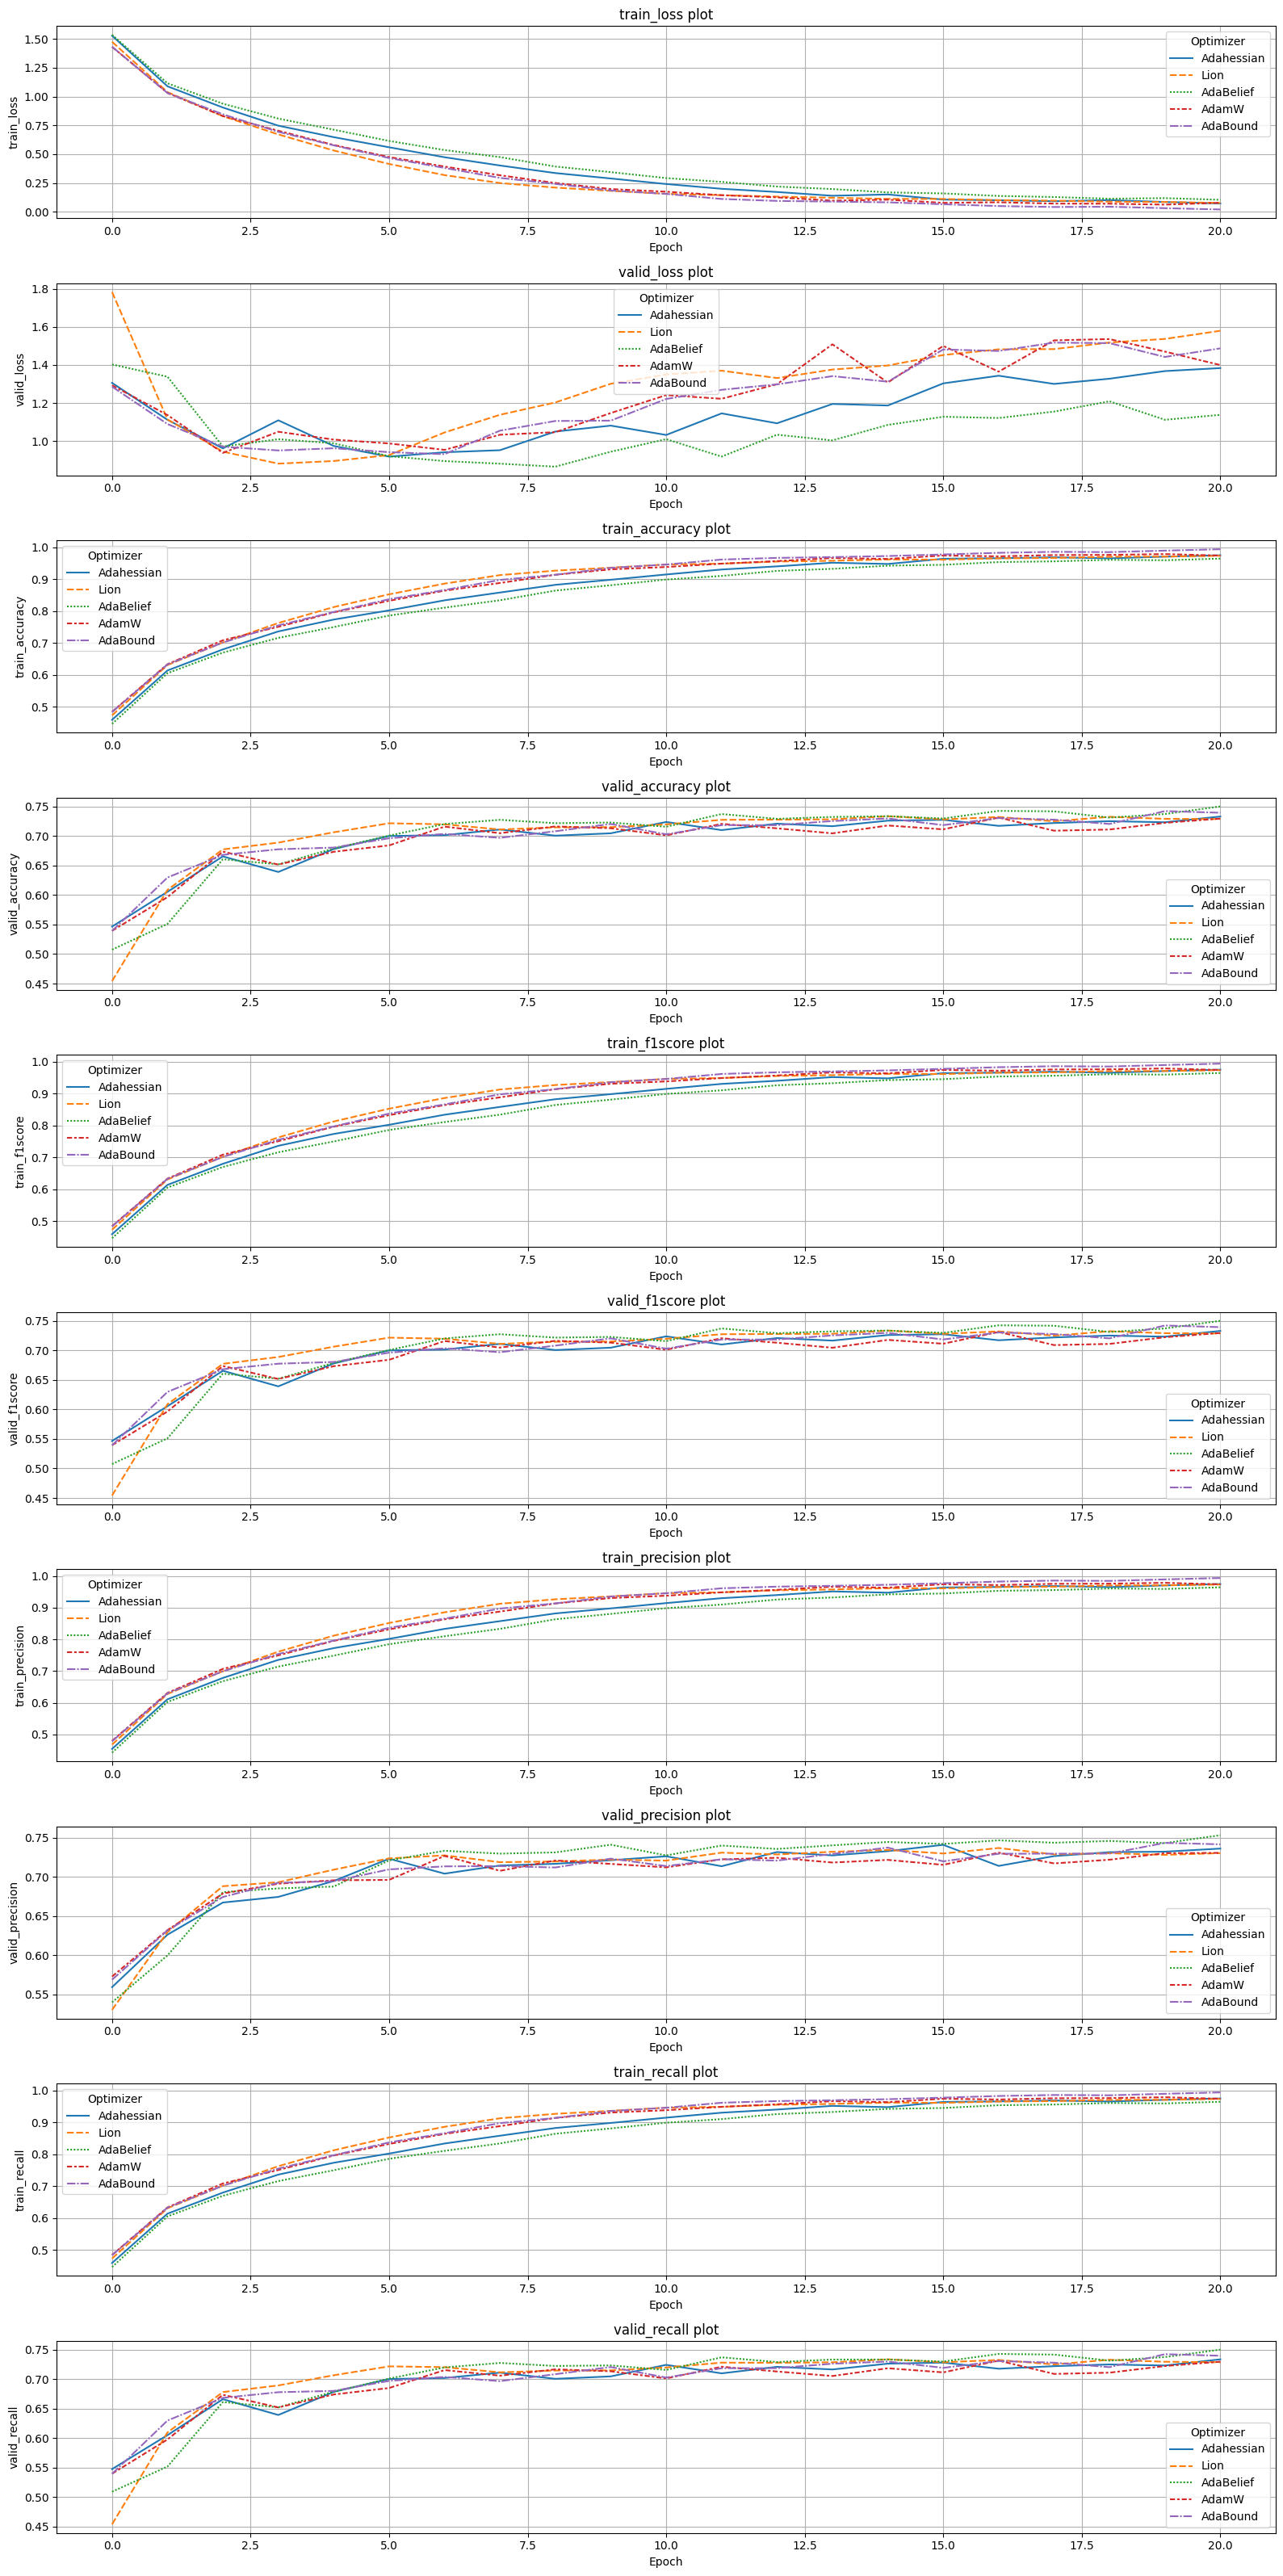

In [18]:
exclude_metrics = ["train_confusion_matrix", "valid_confusion_matrix", "train_multiclass_roc", "valid_multiclass_roc", "time_training"]
plot_results(results, exclude_metrics=exclude_metrics, test_num_epochs=TEST_NUM_EPOCHS, epoch_step=TEST_EPOCH_STEP)

**Анализ графиков:**

На train_loss графике вид кривых достаточно похож. Lion показывает более быструю сходимость, AdaBelief самую медленную.  
На valid_loss видно, что модели достагают минимума примерно на 5 эпохе, после чего loss начинает возрастать, что может означает переобучение моделей.  
На остальных графиках видно хорошую сходимость Lion и AdamW, достаточно шумными оказались Adahessian и AdaBelief.

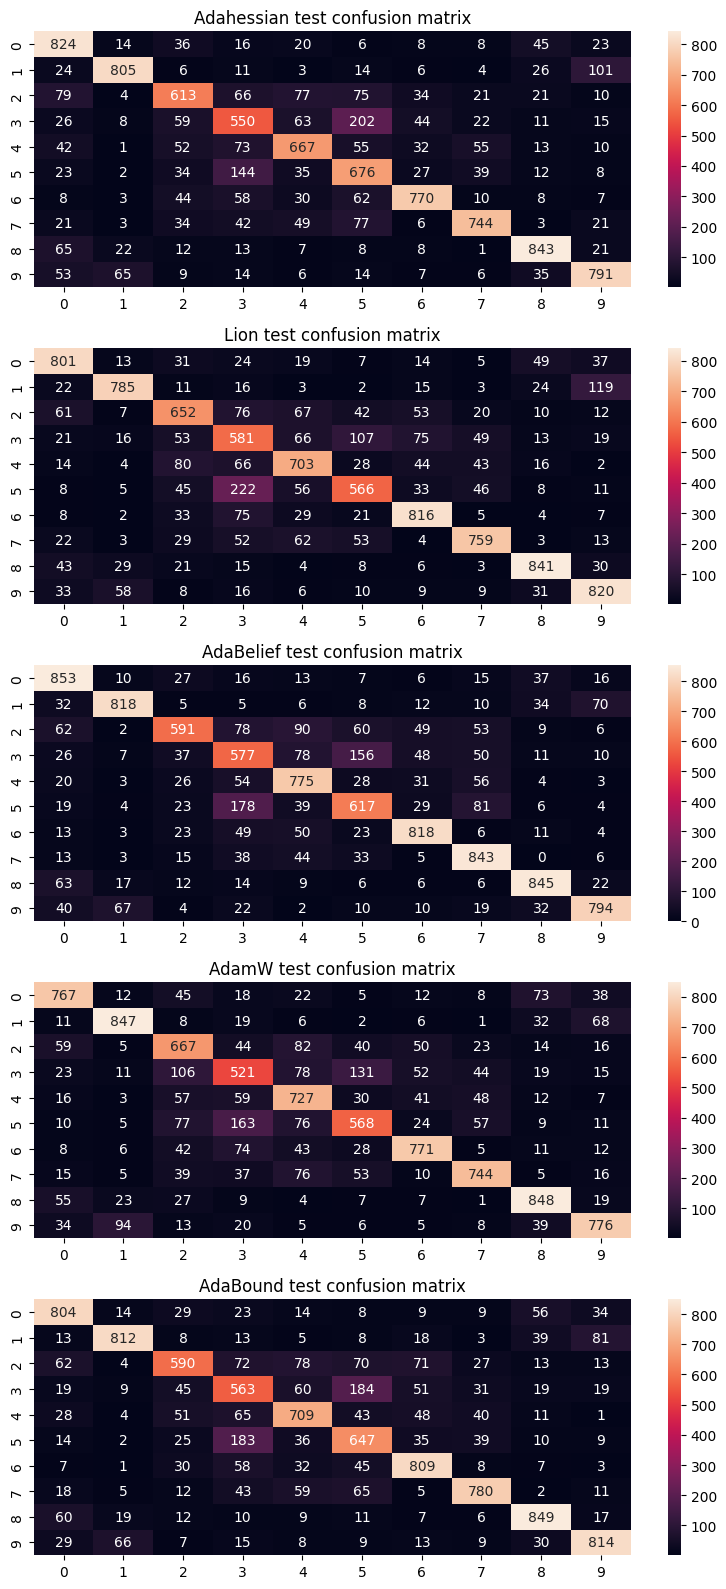

In [19]:
plot_confusion_matrices_results(results)

Видно, что для всех оптимизаторов достаточно проблемным остается отличить 3 класс от 5 и наоборот. Lion лучше всех смог отличить 3 класс от 5, но ошибочно приписывает объекты класса 5 к классу 3, наоборот ситуация с Adahessian. Некоторым компромиссом может выступить AdamW, хоть он и больше всех приписывает объекты ко 2 классу.

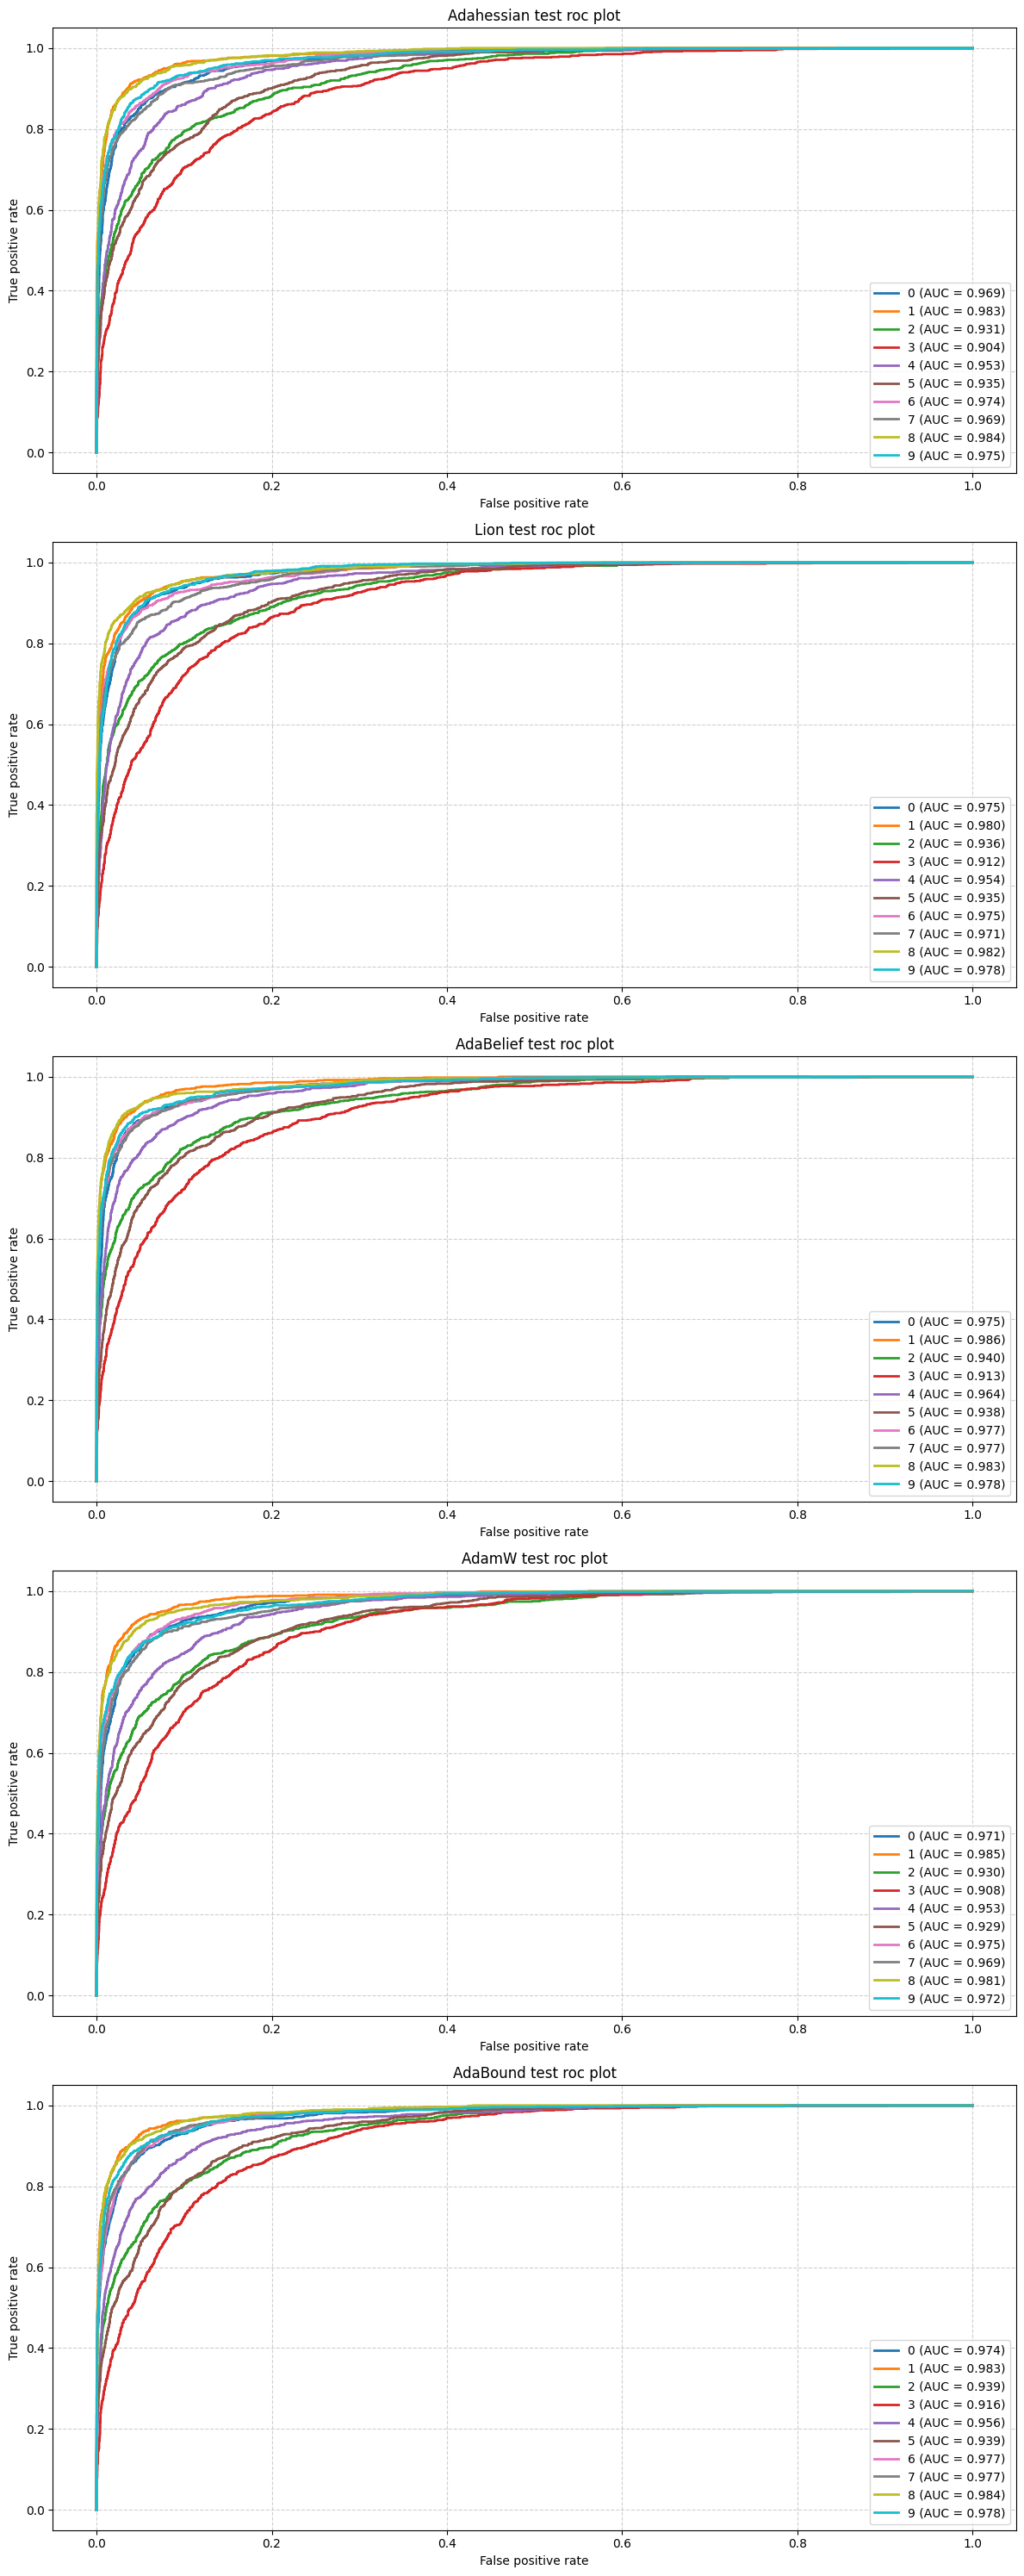

In [20]:
test_plot_roc_results(results=results, num_classes=num_classes)

Вид roc-кривых достаточно схож для всех оптимизаторов.